In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tqdm import tqdm

# фиксируем seed
SEED = 5
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# определяем устройство и batch size
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 512
print(f"device: {device}")


device: cuda


Реализуем EarlyStopping чтобы автоматически прерывать обучение, когда валидационная ошибка перестаёт улучшаться


In [2]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        """
        - patience: сколько эпох подряд без улучшения можно терпеть
        - min_delta: минимальный прирост улучшения
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = np.inf
        self.counter = 0
        self.should_stop = False

    def __call__(self, loss):
        if loss < self.best_loss - self.min_delta:
            self.best_loss = loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


### Загрузка и первичная подготовка данных

In [3]:
DATA_PATH = os.getenv("DATA_PATH", "../data/data.csv")
df = pd.read_csv(DATA_PATH, parse_dates=["ann_date"])
df["log_price"] = np.log1p(df["car_price"])

print(df.head())
print(f"Dataset shape: {df.shape}")


   Unnamed: 0 car_make car_model       car_gen       car_type car_compl  \
0           0   Abarth       500  I Рестайлинг      Кабриолет     other   
1           1   Abarth       500            I       Кабриолет     other   
2           2   Abarth       500  I Рестайлинг      Кабриолет     other   
3           3   Abarth       500            I   Хэтчбек 3 дв.     other   
4           4   Abarth       500  I Рестайлинг  Хэтчбек 3 дв.     other   

    ann_date  car_price         ann_city      avail  ...  seat_count_max  \
0 2024-10-30       2.70          Обнинск  В наличии  ...               4   
1 2024-03-17       1.40            Минск  В наличии  ...               5   
2 2024-09-19       2.99  Санкт-Петербург  В наличии  ...               4   
3 2024-08-15       2.10           Москва  В наличии  ...               4   
4 2024-10-14       1.65           Москва  В наличии  ...               4   

   clearence_max v_bag_max  acc_capacity  age                  age_mod  \
0            104  

In [4]:
drop_cols = ["car_price", "log_price", "ann_date", "Unnamed: 0"]
X = df.drop(columns=drop_cols, errors="ignore")
y = df["log_price"]

print(f"Features: {X.columns.tolist()}")


Features: ['car_make', 'car_model', 'car_gen', 'car_type', 'car_compl', 'ann_city', 'avail', 'year', 'mileage', 'color', 'eng_size', 'eng_power', 'eng_type', 'pow_resrv', 'options', 'transmission', 'drive', 'st_wheel', 'count_owner', 'original_pts', 'state_mark', 'class_auto', 'door_count', 'long', 'width', 'height', 'v_tank', 'curb_weight', 'front_brakes', 'rear_brakes', 'max_speed', 'acceleration', 'fuel_cons', 'fuel_brand', 'engine_loc1', 'engine_loc2', 'turbocharg', 'max_torq', 'cyl_count', 'seat_count_max', 'clearence_max', 'v_bag_max', 'acc_capacity', 'age', 'age_mod', 'mileage_mod', 'acceleration_mod', 'cyl_count_mod']


In [ ]:
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.1, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=SEED)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (94324, 48), Val: (23581, 48), Test: (13101, 48)


Выделяем численные, категориальные с низкой и высокой мощностью

Классифицируем фичи: числовые для скейлинга, low-card (≤20 уникальных) для one-hot encoding, high-card (>20) для эмбеддингов и ordinal encoder, так по идее редкие категории не улетают

In [6]:
num_cols = X_train.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object","category"]).columns.tolist()
high_card = [c for c in cat_cols if X_train[c].nunique() > 20]
low_card  = [c for c in cat_cols if X_train[c].nunique() <= 20]

print("num cols:", num_cols)
print("High cols:", high_card)
print("Low cols:", low_card)


num cols: ['year', 'mileage', 'eng_size', 'eng_power', 'pow_resrv', 'count_owner', 'door_count', 'long', 'width', 'height', 'v_tank', 'curb_weight', 'max_speed', 'acceleration', 'fuel_cons', 'max_torq', 'cyl_count', 'seat_count_max', 'clearence_max', 'v_bag_max', 'acc_capacity', 'age', 'mileage_mod', 'acceleration_mod', 'cyl_count_mod']
High cols: ['car_make', 'car_model', 'car_gen', 'car_type', 'car_compl', 'ann_city', 'options', 'state_mark', 'age_mod']
Low cols: ['avail', 'color', 'eng_type', 'transmission', 'drive', 'st_wheel', 'original_pts', 'class_auto', 'front_brakes', 'rear_brakes', 'fuel_brand', 'engine_loc1', 'engine_loc2', 'turbocharg']


#### Функция для построения препроцессора

Собираем пайплайн, StandardScaler для чисел, OneHotEncoder для малой кардинальности, OrdinalEncoder для больших категорий с резервом на unknown

In [7]:
def build_preprocessor(df, num_cols, low_card, high_card):
    # pipeline для численных StandardScaler
    num_pipe = Pipeline([("scaler", StandardScaler())])
    # pipeline для low-card OneHotEncoder
    ohe_pipe = Pipeline([("onehot", OneHotEncoder(
        handle_unknown="ignore", drop="first", sparse_output=False
    ))])

    # для каждой high-card создаём свой ordinal-энкодер
    high_cat_pipelines = []
    for c in high_card:
        n_uniques = df[c].nunique()
        high_cat_pipelines.append((
            f"ord_{c}",
            Pipeline([("ordinal", OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=n_uniques
            ))]),
            [c]
        ))

    return ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            *high_cat_pipelines,
            ("low_cat", ohe_pipe, low_card),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

# препроцессор на train
preprocessor = build_preprocessor(X_train, num_cols, low_card, high_card)


#### Функция расчёта размеров embedding

Для каждого high-cardinality признака берём половину числа уникальных значений, но не больше 50 и не меньше 2, показалось самой нормальной настройкой

In [8]:
def get_emb_dims(cols, df, max_dim=50):
    emb_dims = []
    for c in cols:
        n_classes = df[c].nunique() + 1
        emb_dim = min(max_dim, max(2, n_classes // 2))
        emb_dims.append((n_classes, emb_dim))
    return emb_dims

emb_dims = get_emb_dims(high_card, X_train)
print("Embedding dims:", dict(zip(high_card, emb_dims)))


Embedding dims: {'car_make': (229, 50), 'car_model': (2004, 50), 'car_gen': (392, 50), 'car_type': (27, 13), 'car_compl': (952, 50), 'ann_city': (129, 50), 'options': (3115, 50), 'state_mark': (25, 12), 'age_mod': (94, 47)}


#### Класс Dataset

Делаем Dataset, который разделяет тензоры на числовые и категориальные части


In [9]:
class CarDataset(Dataset):
    def __init__(self, X_enc, y, n_num, n_cat):
        arr = X_enc if isinstance(X_enc, np.ndarray) else X_enc.values
        self.x = torch.from_numpy(arr).float()
        self.y = torch.from_numpy(y.values.astype(np.float32)).unsqueeze(1)
        self.n_num, self.n_cat = n_num, n_cat
        self.x_num = self.x[:, :n_num]
        self.x_cat = self.x[:, n_num:].long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x_num[idx], self.x_cat[idx], self.y[idx]


#### (Сlass CarRegressor) Определение модели с embedding + MLP

CarRegressor склеивает эмбеды с числовыми признаками и ведет их через MLP с BatchNorm, ReLU и Dropout


In [10]:
class CarRegressor(nn.Module):
    def __init__(self, n_num, emb_dims, hidden_sizes=[128,64], dropout=0.5):
        super().__init__()
        # Embedding слои
        self.emb_layers = nn.ModuleList([nn.Embedding(n, d) for n, d in emb_dims])
        emb_out = sum(d for _, d in emb_dims)

        # построение MLP
        layers, in_f = [], n_num + emb_out
        for h in hidden_sizes:
            layers += [
                nn.Linear(in_f, h),
                nn.BatchNorm1d(h),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout)
            ]
            in_f = h
        layers.append(nn.Linear(in_f, 1))
        self.net = nn.Sequential(*layers)

        # инициализация весов
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.constant_(m.bias, 0.0)

    def forward(self, x_num, x_cat):
        embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.emb_layers)]
        x = torch.cat([x_num, *embs], dim=1)
        return self.net(x)

def build_model(n_num, emb_dims, hidden_sizes=[128,64], dropout=0.5, device=None):
    model = CarRegressor(n_num, emb_dims, hidden_sizes, dropout)
    return model.to(device or device)


#### Функции обучения и оценки

- train_one_epoch учит модель по MSE, ограничивает градиенты, возвращает средний loss 
- evaluate возвращает RMSE, MAE, R2


In [11]:
def train_one_epoch(model, dl, optimizer, loss_fn):
    model.train()
    total_loss = 0.0
    for x_num, x_cat, yb in tqdm(dl, desc="Training"):
        x_num, x_cat, yb = x_num.to(device), x_cat.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(x_num, x_cat), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * x_num.size(0)
    return total_loss / len(dl.dataset)

def evaluate(model, dl):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x_num, x_cat, yb in tqdm(dl, desc="Evaluating"):
            x_num, x_cat = x_num.to(device), x_cat.to(device)
            out = model(x_num, x_cat).cpu().numpy().ravel()
            preds.extend(out)
            trues.extend(yb.numpy().ravel())
    return {
        "rmse": np.sqrt(mean_squared_error(trues, preds)),
        "mae":   mean_absolute_error(trues, preds),
        "r2":    r2_score(trues, preds)
    }


### Грид-поиск по гиперпараметрам

Перебираем dropout, weight_decay и learning_rate, выбираем по минимальному RMSE на валидации


In [12]:
best = {"rmse": np.inf}
for drop in [0.3, 0.5, 0.7]:
    for wd in [1e-5, 1e-4, 1e-3]:
        for lr in [1e-4, 1e-3, 1e-2]:
            Xt = preprocessor.fit_transform(X_train)
            Xv = preprocessor.transform(X_val)

            n_num = Xt.shape[1] - len(high_card)
            dl_tr = DataLoader(CarDataset(Xt, y_train, n_num, len(high_card)),
                               batch_size=BATCH_SIZE, shuffle=True)
            dl_va = DataLoader(CarDataset(Xv, y_val, n_num, len(high_card)),
                               batch_size=BATCH_SIZE)

            model = build_model(n_num, emb_dims, dropout=drop).to(device)
            opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

            for _ in range(5):
                train_one_epoch(model, dl_tr, opt, nn.MSELoss())
            rmse = evaluate(model, dl_va)["rmse"]

            print(f"drop={drop}, wd={wd}, lr={lr} -> RMSE={rmse:.4f}")
            if rmse < best["rmse"]:
                best.update(drop=drop, wd=wd, lr=lr, rmse=rmse)

print("Best hypers:", best)


Evaluating: 100%|██████████| 47/47 [00:00<00:00, 161.39it/s]


drop=0.3, wd=1e-05, lr=0.0001 -> RMSE=0.3332


Evaluating: 100%|██████████| 47/47 [00:00<00:00, 240.52it/s]


drop=0.3, wd=1e-05, lr=0.001 -> RMSE=0.2243


Evaluating: 100%|██████████| 47/47 [00:00<00:00, 247.20it/s]


...

drop=0.7, wd=0.001, lr=0.0001 -> RMSE=0.6973


Evaluating: 100%|██████████| 47/47 [00:00<00:00, 236.23it/s]


drop=0.7, wd=0.001, lr=0.001 -> RMSE=0.4162


Evaluating: 100%|██████████| 47/47 [00:00<00:00, 239.55it/s]

drop=0.7, wd=0.001, lr=0.01 -> RMSE=0.4958
Best hypers: {'rmse': np.float64(0.22431943306066504), 'drop': 0.3, 'wd': 1e-05, 'lr': 0.001}


Полная предобработка и загрузчики для финального обучения, треним на train+val сразу с ReduceLROnPlateau, чтобы LR падал при остановке валидации, и EarlyStopping, чтобы отрубить обучение при отсутствии прогресса


In [13]:
preprocessor_full = build_preprocessor(X_trainval, num_cols, low_card, high_card)
X_full     = preprocessor_full.fit_transform(X_trainval)
X_val_enc  = preprocessor_full.transform(X_val)
X_test_enc = preprocessor_full.transform(X_test)

emb_dims_full = get_emb_dims(high_card, X_trainval)
n_num_full    = X_full.shape[1] - len(high_card)


In [14]:
dl_full      = DataLoader(CarDataset(X_full, y_trainval, n_num_full, len(high_card)),
                          batch_size=BATCH_SIZE, shuffle=True)
dl_val_final = DataLoader(CarDataset(X_val_enc, y_val, n_num_full, len(high_card)),
                          batch_size=BATCH_SIZE)
dl_test      = DataLoader(CarDataset(X_test_enc, y_test, n_num_full, len(high_card)),
                          batch_size=BATCH_SIZE)

In [15]:
model = build_model(n_num_full, emb_dims_full, dropout=best['drop']).to(device)
opt   = torch.optim.Adam(model.parameters(),
                         lr=best['lr'],
                         weight_decay=best['wd'])
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', patience=3)
stopper = EarlyStopping(patience=5, min_delta=0.0)


Обучаем модели, обучаем до 50 эпох с учётом ReduceLROnPlateau и EarlyStopping


In [16]:
hist = {'train': [], 'val': [], 'r2': []}
for epoch in range(1, 51):
    tr_loss = train_one_epoch(model, dl_full, opt, nn.MSELoss())
    vm      = evaluate(model, dl_val_final)

    hist['train'].append(tr_loss)
    hist['val'].append(vm['rmse'])
    hist['r2'].append(vm['r2'])

    print(f"Epoch {epoch}: train={tr_loss:.4f}, val={vm['rmse']:.4f}, r2={vm['r2']:.4f}")

    sched.step(vm['rmse'])
    stopper(vm['rmse'])
    if stopper.should_stop:
        print(f"Early stopping at epoch {epoch}")
        break


Evaluating: 100%|██████████| 47/47 [00:00<00:00, 246.92it/s]


Epoch 1: train=0.5305, val=0.3042, r2=0.7845


Evaluating: 100%|██████████| 47/47 [00:00<00:00, 242.51it/s]


Epoch 2: train=0.1737, val=0.2442, r2=0.8611


Evaluating: 100%|██████████| 47/47 [00:00<00:00, 254.31it/s]


...

Epoch 17: train=0.0483, val=0.1833, r2=0.9218


Evaluating: 100%|██████████| 47/47 [00:00<00:00, 238.52it/s]


Epoch 18: train=0.0475, val=0.1902, r2=0.9157


Evaluating: 100%|██████████| 47/47 [00:00<00:00, 242.02it/s]

Epoch 19: train=0.0468, val=0.1840, r2=0.9211
Early stopping at epoch 19


### Строим графики потерь, R² и scatter plot

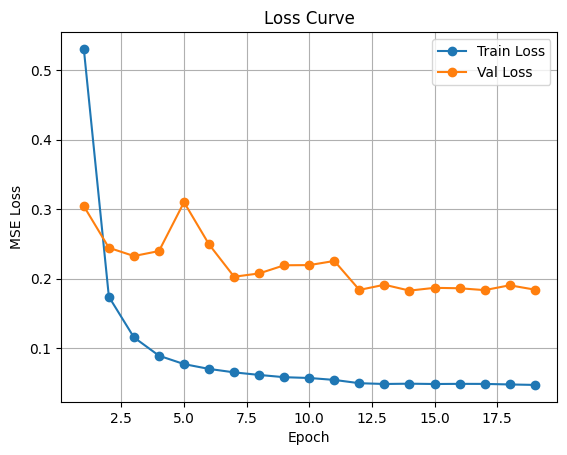

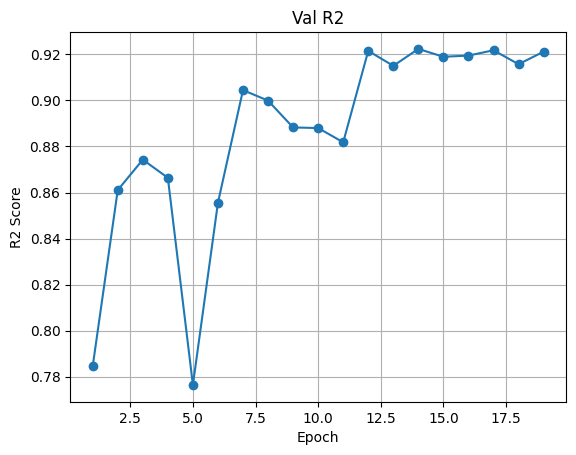

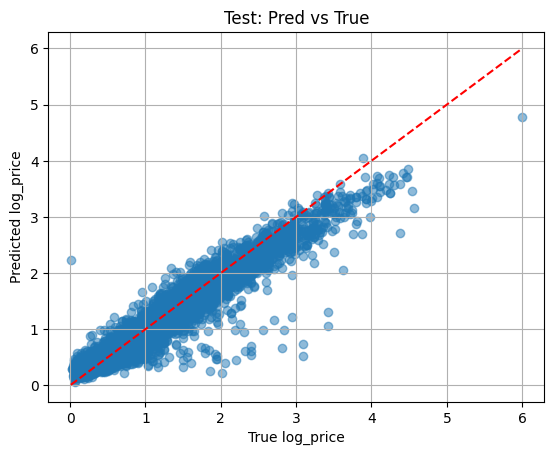

In [17]:
def plot_loss(history):
    ep = range(1, len(history["train"]) + 1)
    plt.figure()
    plt.plot(ep, history["train"], "o-", label="Train Loss")
    plt.plot(ep, history["val"],   "o-", label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
    plt.title("Loss Curve"); plt.legend(); plt.grid(True); plt.show()

def plot_r2_curve(history):
    ep = range(1, len(history["r2"]) + 1)
    plt.figure()
    plt.plot(ep, history["r2"], "o-", label="Val R2")
    plt.xlabel("Epoch"); plt.ylabel("R2 Score")
    plt.title("Val R2"); plt.grid(True); plt.show()

def plot_pred_vs_true(model, dl, title="Pred vs True"):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xn, xc, yb in dl:
            xn, xc = xn.to(device), xc.to(device)
            out = model(xn, xc).cpu().numpy().ravel()
            preds.extend(out); trues.extend(yb.numpy().ravel())
    plt.figure()
    plt.scatter(trues, preds, alpha=0.5)
    mn, mx = min(trues+preds), max(trues+preds)
    plt.plot([mn, mx], [mn, mx], "r--")
    plt.xlabel("True log_price"); plt.ylabel("Predicted log_price")
    plt.title(title); plt.grid(True); plt.show()

plot_loss(hist)
plot_r2_curve(hist)
plot_pred_vs_true(model, dl_test, title="Test: Pred vs True")


### Итоговая оценка на тестовом наборе

Считаем RMSE, MAE и R² в лог и оригинальном масштабе


In [18]:
metrics = evaluate(model, dl_test)
print(f"Test RMSE log-scale: {metrics['rmse']:.4f}")
print(f"Test MAE log-scale: {metrics['mae']:.4f}")
print(f"Test R2 log-scale: {metrics['r2']:.4f}")

# перобразуем логарифм для интерпретируемых цен
preds, trues = [], []
model.eval()
with torch.no_grad():
    for x_num, x_cat, yb in dl_test:
        out = model(x_num.to(device), x_cat.to(device)).cpu().numpy().ravel()
        preds.extend(out); trues.extend(yb.numpy().ravel())

pred_prices = np.expm1(np.array(preds))
true_prices = np.expm1(np.array(trues))
print(f"Test RMSE orig-scale: {np.sqrt(mean_squared_error(true_prices, pred_prices)):.2f}")
print(f"Test MAE orig-scale: {mean_absolute_error(true_prices, pred_prices):.2f}")
print(f"Test R2 orig-scale: {r2_score(true_prices, pred_prices):.4f}")


Evaluating: 100%|██████████| 26/26 [00:00<00:00, 110.09it/s]


Test RMSE log-scale: 0.1885
Test MAE log-scale: 0.1270
Test R2 log-scale: 0.9158
Test RMSE orig-scale: 3.42
Test MAE orig-scale: 0.66
Test R2 orig-scale: 0.6868


Финальный чек на тесте: log-scale RMSE 0,1885, MAE 0,1270, R² 0,9158, orig-scale RMSE ≈3,42, MAE ≈0,66, R² ≈0,6870

Возможно надо комбинировать с бустингом, чтоб добиться хорошего результата, так как табличные значения (Stacking / Ensemble). Пока что данную задачу, тот же cb или lgbm решают намного лучше